# 1) The data are split intwo files, load the files and merge them according to the first column, which is the index; both the files contain a "class" column, keep both the columnsin the merged filecalling them "class_x" and "class_y"(you can use the mergefunction of pandas dataframes)

In [94]:
import pandas as pd
df_1 = pd.read_csv("./exam_1.csv", index_col=0)
df_1["class_x"] = df_1["class"]
df_1.drop(labels="class", axis=1, inplace=True)

df_2 = pd.read_csv("./exam_2.csv", index_col=0)
df_2["class_y"] = df_2["class"]
df_2.drop(labels="class", axis=1, inplace=True)

df = df_1.merge(df_2, left_index=True, right_index=True)
df = df[sorted(df.columns)]

print(df_1.shape, df_2.shape, df.shape)
df

(2000, 4) (2000, 4) (2000, 8)


,A,B,C,D,E,F,class_x,class_y
0,-0.386248,-1.432057,1.536628,1.039420,1.232589,0.280469,1,1
1,-2.686649,-4.036329,4.640702,0.526320,0.823433,-0.419013,1,1
2,0.474124,0.179770,1.576616,0.157974,-1.256234,-0.162869,0,0
3,-1.343790,-1.299109,-0.514008,-0.152250,1.520392,0.045123,2,2
4,-2.187600,-2.089699,0.289041,-0.494995,1.318321,-0.661858,2,2
...,...,...,...,...,...,...,...,...
1995,-1.668710,-1.114765,1.258125,-1.209808,-1.111517,1.546161,0,0
1996,0.842932,1.188689,-0.862210,-0.174914,-0.658845,-1.376579,2,2
1997,1.371652,0.929550,0.861149,0.616987,-0.966656,-0.643962,0,0
1998,2.091386,1.918095,-0.164420,0.557593,-1.185916,-0.942563,0,0


# 2) Delete all the rows whereclass_xis different from class_y, then drop class_yand rename class_xas class

In [95]:
mask = (df["class_x"] == df["class_y"])
df_filtered = df[mask].drop(labels="class_y", axis=1).rename(columns={"class_x":"class"})
df_filtered

,A,B,C,D,E,F,class
0,-0.386248,-1.432057,1.536628,1.039420,1.232589,0.280469,1
1,-2.686649,-4.036329,4.640702,0.526320,0.823433,-0.419013,1
2,0.474124,0.179770,1.576616,0.157974,-1.256234,-0.162869,0
3,-1.343790,-1.299109,-0.514008,-0.152250,1.520392,0.045123,2
4,-2.187600,-2.089699,0.289041,-0.494995,1.318321,-0.661858,2
...,...,...,...,...,...,...,...
1995,-1.668710,-1.114765,1.258125,-1.209808,-1.111517,1.546161,0
1996,0.842932,1.188689,-0.862210,-0.174914,-0.658845,-1.376579,2
1997,1.371652,0.929550,0.861149,0.616987,-0.966656,-0.643962,0
1998,2.091386,1.918095,-0.164420,0.557593,-1.185916,-0.942563,0


# 3) Reorder the columns inalphabetical order, but placing the classcolumn as the last one; the cleaned dataframe must be named df;show its size and head

column operations has been done before

In [96]:
df = df_filtered.copy()
print(df.shape)
df.head()

(1984, 7)


,A,B,C,D,E,F,class
0,-0.386248,-1.432057,1.536628,1.039420,1.232589,0.280469,1
1,-2.686649,-4.036329,4.640702,0.526320,0.823433,-0.419013,1
2,0.474124,0.179770,1.576616,0.157974,-1.256234,-0.162869,0
3,-1.343790,-1.299109,-0.514008,-0.152250,1.520392,0.045123,2
4,-2.187600,-2.089699,0.289041,-0.494995,1.318321,-0.661858,2


# 4) Find the best classification scheme using three classification methods

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

random_state=42
models = {
    
    # Decision Tree
    "dt" : {
        "name" : "Decision Tree",
        "estimator" : DecisionTreeClassifier(random_state=random_state),
        "params" : [{
            "criterion" : ["gini", "entropy", "log_loss"],
            "splitter" : ["best", "random"],
            "max_depth" : [*range(1, 21)]
        }]
    },
    
    # K Nearest Neighbors
    'knn': {
        'name' : 'K Nearest Neighbor ',
        'estimator' : KNeighborsClassifier(n_jobs=-1),
        "params" : [{
            "n_neighbors" : [*range(1,21)],
            "weights" : ["uniform", "distance"],
            "algorithm" : ["auto", "ball_tree", "kd_tree", "brute"]
        }]
    },
    
    # Random Forest
    "rf" : {
        'name' : 'Random Forest ',
        'estimator' : RandomForestClassifier(n_jobs=-1, random_state=random_state),
        "params" : [{
            "criterion" : ["gini", "entropy", "log_loss"],
            "n_estimators" : [*range(10, 101, 10)],
            "max_depth" : [*range(1, 11)] 
        }]
    }
}

In [98]:
target = "class"
X = df.drop(labels=target, axis=1)
y = df[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1488, 6) (496, 6) (1488,) (496,)


# 5) For each classification method find the best parametersetting with cross validation on the trainingset

In [99]:
from sklearn.model_selection import GridSearchCV

best_params = {}
print(f"The best parameters:")
for k, model in models.items():
    gs = GridSearchCV(
        estimator=model["estimator"],
        param_grid=model["params"],
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best_params[k] = gs.best_params_
    print(f"\t{model['name']}: {best_params[k]}")

The best parameters:
	Decision Tree: {'criterion': 'entropy', 'max_depth': 6, 'splitter': 'best'}
	K Nearest Neighbor : {'algorithm': 'auto', 'n_neighbors': 20, 'weights': 'distance'}
	Random Forest : {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}


# 6) For each classification methodcompute the accuracy and the confusion matrixon the test set

In [100]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = {}
accuracy = {}
print(f"Accuracies on the test:")
for k, params in best_params.items():
    model = models[k]["estimator"].set_params(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm[k] = confusion_matrix(y_test, y_pred)    
    accuracy[k] = accuracy_score(y_test, y_pred)   
    print(f"\t{models[k]['name']}: {accuracy[k]}") 

Accuracies on the test:
	Decision Tree: 0.8366935483870968
	K Nearest Neighbor : 0.8508064516129032
	Random Forest : 0.875


# 7) Produce a plot of the accuracies given bythe methods attempted

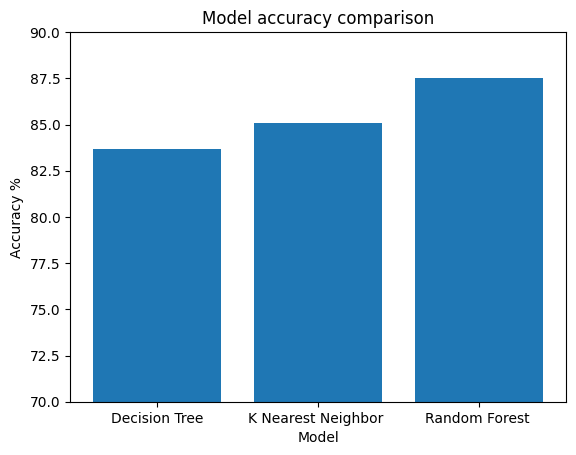

In [101]:
import matplotlib.pyplot as plt
names = [models[k]["name"] for k in accuracy.keys()]
accuracies = [acc*100 for acc in accuracy.values()]

plt.title("Model accuracy comparison")
plt.bar(names, accuracies);
plt.ylabel("Accuracy %")
plt.xlabel("Model")
plt.ylim(70,90)
plt.show()